# LSEG Data Pull — NetPayout

Dieses Notebook nutzt den `lseg_series_puller`.

Pipeline:
- `1.` Setup
- `2.` Input + Run-Konfiguration
- `3.` Optionaler Reset (Fresh Run)
- `4.` Standard Puller Setup
- `5.` Balance Sheet Pull
- `6.` Income Statement Pull
- `7.` Payout Pulls (Dividends + Buybacks)
- `8.` Liquidity Pull
- `9.` Market Cap Pull
- `10.` Coverage-Plot nach Quartal
- `11.` Finaler Output


## 1. Setup


In [1]:
from pathlib import Path
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lseg_series_puller import (
    SeriesPullConfig,
    SeriesFieldSpec,
    run_standard_pull,
)
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 200)
set_global_plot_style()


## 2. Input + Run-Konfiguration

Geladene Basisdaten:
- `Project_Data/intermediate/euro500.parquet`

Verwendete Schlüsselspalten:
- `firm_id`
- `date`
- (ID-Fallback aus vorhandenen Spalten wie `ISIN`, `RIC_current`, `RIC`, `id_type`, `pull_id`)


In [2]:
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH = DATA_DIR / 'euro500_netpayout.parquet'

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')

base = pd.read_parquet(BASE_PATH).copy()
if 'date' not in base.columns or 'firm_id' not in base.columns:
    raise ValueError('euro500.parquet must contain at least firm_id and date columns.')

base['date'] = pd.to_datetime(base['date'], errors='coerce').dt.normalize()
base = base.dropna(subset=['firm_id']).copy()

# ---------- Candidate overrides from full ID history ----------
ALL_ID_CANDIDATE_OVERRIDES = {}

for firm_id, g in base.groupby('firm_id', sort=False):
    seen = set()
    cands = []

    def _add(it: str, v: object) -> None:
        if pd.isna(v):
            return
        val = str(v).strip()
        if not val:
            return
        typ = str(it).strip().upper()
        if typ == 'ISIN' and val.upper().startswith('ISIN:'):
            val = val.split(':', 1)[1].strip()
        if typ not in {'ISIN', 'RIC'} or not val:
            return
        key = (typ, val)
        if key in seen:
            return
        seen.add(key)
        cands.append(key)

    for col, typ in [('ISIN', 'ISIN'), ('RIC_current', 'RIC'), ('RIC', 'RIC')]:
        if col in g.columns:
            for v in g[col].dropna().astype(str):
                _add(typ, v)

    if {'id_type', 'pull_id'}.issubset(g.columns):
        hist = g[['id_type', 'pull_id']].dropna()
        for _, row in hist.iterrows():
            _add(str(row['id_type']).upper().strip(), row['pull_id'])

    if cands:
        ALL_ID_CANDIDATE_OVERRIDES[str(firm_id)] = cands

# ---------- Universal Pull Panel — jährlich (alle Fundamentaldaten) ----------
PULL_START_DATE = pd.Timestamp('1995-12-31')
PULL_END_DATE   = pd.Timestamp('2025-12-31')
PULL_FREQ       = 'YE-DEC'

# ---------- Monatliches Pull Panel — nur für NP5 (Market Cap) ----------
PULL_FREQ_MONTHLY = 'ME'


def _first_valid(series: pd.Series):
    x = series.dropna()
    return x.iloc[0] if not x.empty else pd.NA


id_cols = [c for c in ['ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', 'company_name'] if c in base.columns]
firm_meta = (
    base[['firm_id', *id_cols]].copy()
    .groupby('firm_id', as_index=False)
    .agg({c: _first_valid for c in id_cols})
)

# Jährlicher pull_base (NP1–NP4, NP6)
pull_dates = pd.date_range(PULL_START_DATE, PULL_END_DATE, freq=PULL_FREQ).normalize()
pull_calendar = pd.DataFrame({'date': pull_dates})
firm_meta['_k'] = 1
pull_calendar['_k'] = 1
pull_base = firm_meta.merge(pull_calendar, on='_k', how='inner').drop(columns=['_k'])
pull_base = pull_base[['firm_id', 'date', *id_cols]].sort_values(['firm_id', 'date']).reset_index(drop=True)

# Monatlicher pull_base (NP5: Market Cap)
pull_dates_monthly = pd.date_range(PULL_START_DATE, PULL_END_DATE, freq=PULL_FREQ_MONTHLY).normalize()
pull_calendar_monthly = pd.DataFrame({'date': pull_dates_monthly})
firm_meta['_k'] = 1
pull_calendar_monthly['_k'] = 1
pull_base_monthly = firm_meta.merge(pull_calendar_monthly, on='_k', how='inner').drop(columns=['_k'])
pull_base_monthly = pull_base_monthly[['firm_id', 'date', *id_cols]].sort_values(['firm_id', 'date']).reset_index(drop=True)

cand_counts = pd.Series({k: len(v) for k, v in ALL_ID_CANDIDATE_OVERRIDES.items()})
print('Loaded source index:', BASE_PATH)
print('source rows:', len(base), '| companies:', base['firm_id'].nunique())
print('source date range:', base['date'].min(), '->', base['date'].max())
print('Annual pull panel rows:', len(pull_base), '| companies:', pull_base['firm_id'].nunique())
print('Monthly pull panel rows:', len(pull_base_monthly), '| companies:', pull_base_monthly['firm_id'].nunique())
print('pull date range:', pull_base['date'].min(), '->', pull_base['date'].max(), '| freq:', PULL_FREQ)
if not cand_counts.empty:
    print('ID candidate overrides: firms=', len(cand_counts), '| median=', int(cand_counts.median()), '| p95=', int(cand_counts.quantile(0.95)), '| max=', int(cand_counts.max()))

# ---------- Run control ----------
RESET_PULL_STATE  = False
FORCE_REFRESH_ALL = False
RUN_LSEG_PULL     = True
BATCH_SIZE        = 10
ASOF_TOL_DAYS     = 45
DEBUG_RAW_FIRST_N = 0
PRE_INDEX_PREFETCH_YEARS = 0

# Wenn True, wird auch das finale Output-Parquet entfernt und neu aufgebaut.
RESET_OUTPUT_FILE = False


Loaded source index: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
source rows: 56500 | companies: 1248
source date range: 1997-12-31 00:00:00 -> 2025-12-31 00:00:00
Annual pull panel rows: 38688 | companies: 1248
Monthly pull panel rows: 450528 | companies: 1248
pull date range: 1995-12-31 00:00:00 -> 2025-12-31 00:00:00 | freq: YE-DEC
ID candidate overrides: firms= 1248 | median= 2 | p95= 4 | max= 8


## 3. Reset (optional, für kompletten Neu-Pull)

Wenn aktiviert, werden pro Modul gelöscht:
- Cache-Verzeichnisse (`*_cache_by_company_id`)
- `step_rows`-Dateien
- `checkpoint`-Dateien
- `bad_ids`-Dateien
- `bad_rows`-Logs
- optional das kombinierte Output-File `euro500_netpayout.parquet`

(Hintergrund: interne Module `NP1/NP2/NP3/NP4/NP5/NP6`.)


In [3]:
MODULES = {
    'NP1': {
        'cache_dir': CACHE_DATA_DIR / 'np1_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np1_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np1_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np1_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np1_bad_rows.parquet',
    },
    'NP2': {
        'cache_dir': CACHE_DATA_DIR / 'np2_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np2_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np2_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np2_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np2_bad_rows.parquet',
    },
    'NP3': {
        'cache_dir': CACHE_DATA_DIR / 'np3_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np3_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np3_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np3_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np3_bad_rows.parquet',
    },
    'NP4': {
        'cache_dir': CACHE_DATA_DIR / 'np4_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np4_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np4_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np4_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np4_bad_rows.parquet',
    },
    'NP5': {
        'cache_dir': CACHE_DATA_DIR / 'np5_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np5_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np5_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np5_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np5_bad_rows.parquet',
    },
    'NP6': {
        'cache_dir': CACHE_DATA_DIR / 'np6_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np6_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np6_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np6_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np6_bad_rows.parquet',
    },
}

if RESET_PULL_STATE:
    print('Resetting NP pull state...')
    for name, m in MODULES.items():
        if m['cache_dir'].exists():
            shutil.rmtree(m['cache_dir'])
            print(f'  removed cache dir: {m["cache_dir"]}')
        for k in ['step_rows_path', 'checkpoint_path', 'bad_ids_path', 'bad_rows_log_path']:
            fp = m[k]
            if fp.exists():
                fp.unlink()
                print(f'  removed {name} {k}: {fp}')

if RESET_OUTPUT_FILE and OUTPUT_PATH.exists():
    OUTPUT_PATH.unlink()
    print('Removed old output:', OUTPUT_PATH)


## 4. Standard Puller Setup


In [4]:
def run_np_module(
    source_df: pd.DataFrame,
    module_name: str,
    specs: tuple[SeriesFieldSpec, ...],
    primary_output_col: str,
    *,
    reset_state: bool = False,
    skip_known_bad_ids: bool = True,
    max_retries: int = 3,
) -> dict:
    m = MODULES[module_name]

    if reset_state:
        if m['cache_dir'].exists():
            shutil.rmtree(m['cache_dir'])
            print(f'Reset {module_name}: removed cache dir {m["cache_dir"]}')
        for k in ['step_rows_path', 'checkpoint_path', 'bad_ids_path', 'bad_rows_log_path']:
            fp = m[k]
            if fp.exists():
                fp.unlink()
                print(f'Reset {module_name}: removed {k} {fp}')

    cfg = SeriesPullConfig(
        batch_size=BATCH_SIZE,
        asof_tolerance_days=ASOF_TOL_DAYS,
        prefetch_start_days=int(PRE_INDEX_PREFETCH_YEARS * 365),
        debug_raw_first_n=DEBUG_RAW_FIRST_N,
        force_refresh=FORCE_REFRESH_ALL,
        cache_only=(not RUN_LSEG_PULL),
        skip_known_bad_ids=skip_known_bad_ids,
        max_retries=max_retries,
        base_sleep_sec=0.7,
        series_specs=specs,
        primary_output_col=primary_output_col,
        candidate_overrides=ALL_ID_CANDIDATE_OVERRIDES,
    )

    print('\n' + '=' * 90)
    print(f'RUN {module_name}')
    print('=' * 90)

    res = run_standard_pull(
        pull_type='series',
        source_df=source_df,
        config=cfg,
        cache_dir=m['cache_dir'],
        step_rows_path=m['step_rows_path'],
        checkpoint_path=m['checkpoint_path'],
        bad_ids_path=m['bad_ids_path'],
        bad_rows_log_path=m['bad_rows_log_path'],
        skip_filled_primary=False,
        merge_back=True,
        diag_prefix=f'{module_name.lower()}_',
    )

    print(f"{module_name} stats:", res['stats'])
    return res


NP1_SPECS = (
    SeriesFieldSpec(output_col='BE',     fields=('TR.F.COMEQTOT(Period=FY0)',)),
    SeriesFieldSpec(output_col='assets', fields=('TR.F.TOTASSETS(Period=FY0)',)),
    SeriesFieldSpec(output_col='debt',   fields=('TR.F.DEBTTOT(Period=FY0)',)),
)

NP2_SPECS = (
    SeriesFieldSpec(output_col='Sales',       fields=('TR.F.TotRevenue(Period=FY0)',)),
    SeriesFieldSpec(output_col='NetIncome',   fields=('TR.F.NetIncAfterTax(Period=FY0)',)),
    SeriesFieldSpec(output_col='GrossProfit', fields=('TR.F.GrossProfIndPropTot(Period=FY0)',)),
    SeriesFieldSpec(output_col='Cogs',        fields=('TR.F.COGSTot(Period=FY0)',)),
)

# NP3: Dividends only.
NP3_SPECS = (
    SeriesFieldSpec(output_col='Dividends', fields=('TR.F.DivPaidCashTotCF(Period=FY0)',)),
)

# NP6: Buybacks only (separate pull for higher payout coverage control).
NP6_SPECS = (
    SeriesFieldSpec(output_col='Buybacks', fields=('TR.F.ComStockBuybackNet(Period=FY0)',)),
)

# NP4: Liquidity only.
NP4_SPECS = (
    SeriesFieldSpec(output_col='CashSTInvst', fields=('TR.F.CashSTInvst(Period=FY0)',)),
)

# NP5: Market cap — monthly interval reicht für YE-Stichtage.
NP5_SPECS = (
    SeriesFieldSpec(output_col='mcap_eur', fields=('TR.CompanyMarketCap',), intervals=('monthly',)),
)


def coverage_by_quarter(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    x = df.copy()
    x['date'] = pd.to_datetime(x['date'], errors='coerce').dt.normalize()
    x = x.dropna(subset=['firm_id', 'date']).copy()
    x['quarter'] = x['date'].dt.to_period('Q').dt.to_timestamp(how='end').dt.normalize()

    rows = []
    for q, g in x.groupby('quarter', sort=True):
        rec = {
            'quarter': q,
            'n_obs': int(len(g)),
            'n_firms': int(g['firm_id'].nunique()),
        }
        for col in cols:
            if col in g.columns:
                rec[f'cov_{col}_pct'] = round(float(pd.to_numeric(g[col], errors='coerce').notna().mean() * 100.0), 2)
            else:
                rec[f'cov_{col}_pct'] = np.nan
        rows.append(rec)

    out = pd.DataFrame(rows).sort_values('quarter').reset_index(drop=True)
    return out


## 5. Balance Sheet Pull

Geladene LSEG-Daten (FY):
- `TR.F.COMEQTOT(Period=FY0)` -> `BE`
- `TR.F.TOTASSETS(Period=FY0)` -> `assets`
- `TR.F.DEBTTOT(Period=FY0)` -> `debt`

Merge-Ziel:
- zurück auf `euro500` über `firm_id,date`

(Hintergrund: internes Modul `NP1`.)


In [5]:
np1 = run_np_module(pull_base, 'NP1', NP1_SPECS, primary_output_col='BE')
np1_df = np1['merged_df'].copy()
print('NP1 done: rows=', len(np1_df), '| companies=', np1_df['firm_id'].nunique())



RUN NP1

Standard Series Pull Overview
series_specs: BE<-['TR.F.COMEQTOT(Period=FY0)'], assets<-['TR.F.TOTASSETS(Period=FY0)'], debt<-['TR.F.DEBTTOT(Period=FY0)']
request_rows: 38,688
coverage: all_companies=1,248 | full_coverage=143 | partial_coverage=1,101 | bad_ids=4 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_BE=0, full_coverage=143, partial_coverage=1101, bad_ids=4, bad_id_skip=4, bad_ids_added=0, known_bad_ids_now=4
NP1 stats: {'companies_total': 1248, 'full_coverage': 143, 'partial_coverage': 1101, 'bad_ids': 4, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 4, 'bad_ids_added': 0, 'known_bad_ids_now': 4}
NP1 done: rows= 38688 | companies= 1248


### 5.1 Coverage nach Quartal (Balance Sheet)


In [6]:
np1_cov_q = coverage_by_quarter(np1_df, ['BE', 'assets', 'debt'])
np1_cov_q

,quarter,n_obs,n_firms,cov_BE_pct,cov_assets_pct,cov_debt_pct
0,1995-12-31,1248,1248,14.26,14.34,13.62
1,1996-12-31,1248,1248,27.80,27.88,26.20
2,1997-12-31,1248,1248,38.62,38.86,37.02
3,1998-12-31,1248,1248,59.70,59.78,56.41
4,1999-12-31,1248,1248,65.95,66.11,61.86
5,2000-12-31,1248,1248,69.15,69.39,65.22
6,2001-12-31,1248,1248,72.20,72.36,68.59
7,2002-12-31,1248,1248,73.48,73.72,70.67
8,2003-12-31,1248,1248,77.64,77.80,74.28
9,2004-12-31,1248,1248,79.17,79.65,75.72


## 6. Income Statement Pull

Geladene LSEG-Daten (FY):
- `TR.F.TotRevenue(Period=FY0)` -> `Sales`
- `TR.F.NetIncAfterTax(Period=FY0)` -> `NetIncome`
- `TR.F.GrossProfIndPropTot(Period=FY0)` -> `GrossProfit`
- `TR.F.COGSTot(Period=FY0)` -> `Cogs`

Merge-Ziel:
- Update des vorherigen Outputs über `firm_id,date`

(Hintergrund: internes Modul `NP2`.)


In [7]:
_np2_input = np1_df if 'np1_df' in globals() else pull_base
np2 = run_np_module(_np2_input, 'NP2', NP2_SPECS, primary_output_col='Sales')
np2_df = np2['merged_df'].copy()
print('NP2 done: rows=', len(np2_df), '| companies=', np2_df['firm_id'].nunique())



RUN NP2

Standard Series Pull Overview
series_specs: Sales<-['TR.F.TotRevenue(Period=FY0)'], NetIncome<-['TR.F.NetIncAfterTax(Period=FY0)'], GrossProfit<-['TR.F.GrossProfIndPropTot(Period=FY0)'], Cogs<-['TR.F.COGSTot(Period=FY0)']
request_rows: 38,688
coverage: all_companies=1,248 | full_coverage=34 | partial_coverage=155 | bad_ids=1 | remaining=1,058
mode: CACHE+NETWORK | batch_size: 10
[BATCH 1/106] companies=10 idx=1-10
[BATCH 1/106] [1/1058] firm_id=FIRM0000208 | cand_used=3/3 | unresolved=1 | found_Sales=30 | found_NetIncome=30 | found_GrossProfit=30 | found_Cogs=25 | pulled_range=1995-12-31:2024-12-31 | tried_ids: ISIN:FR0000133308 | RIC:ORAN.PA | RIC:FTE.PA
[BATCH 1/106] [2/1058] firm_id=FIRM0000209 | cand_used=5/5 | unresolved=1 | found_Sales=30 | found_NetIncome=30 | found_GrossProfit=30 | found_Cogs=30 | pulled_range=1995-12-31:2024-12-31 | tried_ids: ISIN:NL0000352532 | ISIN:NL0000352565 | ISIN:NL00150003E1 | RIC:FUGR.AS | RIC:FUGRc.AS
[BATCH 1/106] [3/1058] firm_id=FIRM000

### 6.1 Coverage nach Quartal (Income Statement)


In [8]:
np2_cov_q = coverage_by_quarter(np2_df, ['Sales', 'NetIncome', 'GrossProfit', 'Cogs'])
np2_cov_q


,quarter,n_obs,n_firms,cov_Sales_pct,cov_NetIncome_pct,cov_GrossProfit_pct,cov_Cogs_pct
0,1995-12-31,1248,1248,15.14,15.14,12.42,11.14
1,1996-12-31,1248,1248,26.52,26.44,22.28,20.11
2,1997-12-31,1248,1248,36.22,36.14,31.57,28.29
3,1998-12-31,1248,1248,53.45,53.69,47.68,44.55
4,1999-12-31,1248,1248,59.13,59.46,53.12,48.48
5,2000-12-31,1248,1248,62.58,62.74,56.33,51.28
6,2001-12-31,1248,1248,64.10,64.18,57.37,53.61
7,2002-12-31,1248,1248,66.11,66.35,59.70,56.41
8,2003-12-31,1248,1248,70.27,70.19,63.38,60.74
9,2004-12-31,1248,1248,72.44,72.60,65.46,62.74


## 7. Payout Pulls (Dividends + Buybacks)

Wir ziehen Dividends und Buybacks bewusst in getrennten Modulen, um die Coverage gezielt zu verbessern.

- Dividends: `TR.F.DivPaidCashTotCF(Period=FY0)`
- Buybacks: `TR.F.ComStockBuybackNet(Period=FY0)`

(Hintergrund: interne Module `NP3` und `NP6`.)


In [9]:
_np3_input = np2_df if 'np2_df' in globals() else (np1_df if 'np1_df' in globals() else pull_base)
np3 = run_np_module(
    _np3_input,
    'NP3',
    NP3_SPECS,
    primary_output_col='Dividends',
    skip_known_bad_ids=True,
    max_retries=5,
)
np3_df = np3['merged_df'].copy()
np3_df['date'] = pd.to_datetime(np3_df['date'], errors='coerce').dt.normalize()
np3_df = np3_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
print('NP3 (Dividends) done: rows=', len(np3_df), '| companies=', np3_df['firm_id'].nunique())

_np6_input = np3_df.copy()
np6 = run_np_module(
    _np6_input,
    'NP6',
    NP6_SPECS,
    primary_output_col='Buybacks',
    skip_known_bad_ids=True,
    max_retries=5,
)
np6_df = np6['merged_df'].copy()
np6_df['date'] = pd.to_datetime(np6_df['date'], errors='coerce').dt.normalize()
np6_df = np6_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
print('NP6 (Buybacks) done: rows=', len(np6_df), '| companies=', np6_df['firm_id'].nunique())



RUN NP3

Standard Series Pull Overview
series_specs: Dividends<-['TR.F.DivPaidCashTotCF(Period=FY0)']
request_rows: 38,688
coverage: all_companies=1,248 | full_coverage=54 | partial_coverage=1,069 | bad_ids=125 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_Dividends=0, full_coverage=54, partial_coverage=1069, bad_ids=125, bad_id_skip=125, bad_ids_added=0, known_bad_ids_now=125
NP3 stats: {'companies_total': 1248, 'full_coverage': 54, 'partial_coverage': 1069, 'bad_ids': 125, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 125, 'bad_ids_added': 0, 'known_bad_ids_now': 125}
NP3 (Dividends) done: rows= 38688 | companies= 1248

RUN NP6

Standard Series Pull Overview
series_specs: Buybacks<-['TR.F.ComStockBuybackNet(Period=FY0)']
request_rows: 38,688
coverage: all_companies=1,248 | full_coverage=19 | pa

### 7.1 Coverage nach Quartal (Payout)


In [10]:
np3_cov_q = coverage_by_quarter(np3_df, ['Dividends'])
np6_cov_q = coverage_by_quarter(np6_df, ['Buybacks'])
np6_cov_q


,quarter,n_obs,n_firms,cov_Buybacks_pct
0,1995-12-31,1248,1248,5.53
1,1996-12-31,1248,1248,8.97
2,1997-12-31,1248,1248,13.22
3,1998-12-31,1248,1248,21.39
4,1999-12-31,1248,1248,29.17
5,2000-12-31,1248,1248,33.01
6,2001-12-31,1248,1248,34.94
7,2002-12-31,1248,1248,33.01
8,2003-12-31,1248,1248,34.38
9,2004-12-31,1248,1248,43.75


## 8. Liquidity Pull

Geladene LSEG-Daten:
- `TR.F.CashSTInvst(Period=FY0)` -> `CashSTInvst`

(Hintergrund: internes Modul `NP4`.)


In [11]:
_np4_input = np6_df if 'np6_df' in globals() else (np3_df if 'np3_df' in globals() else pull_base)
np4 = run_np_module(
    _np4_input,
    'NP4',
    NP4_SPECS,
    primary_output_col='CashSTInvst',
    skip_known_bad_ids=True,
    max_retries=5,
)
np4_df = np4['merged_df'].copy()
np4_df['date'] = pd.to_datetime(np4_df['date'], errors='coerce').dt.normalize()
np4_df = np4_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
print('NP4 done: rows=', len(np4_df), '| companies=', np4_df['firm_id'].nunique())



RUN NP4

Standard Series Pull Overview
series_specs: CashSTInvst<-['TR.F.CashSTInvst(Period=FY0)']
request_rows: 38,688
coverage: all_companies=1,248 | full_coverage=126 | partial_coverage=1,102 | bad_ids=20 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_CashSTInvst=0, full_coverage=126, partial_coverage=1102, bad_ids=20, bad_id_skip=20, bad_ids_added=0, known_bad_ids_now=20
NP4 stats: {'companies_total': 1248, 'full_coverage': 126, 'partial_coverage': 1102, 'bad_ids': 20, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 20, 'bad_ids_added': 0, 'known_bad_ids_now': 20}
NP4 done: rows= 38688 | companies= 1248


### 8.1 Coverage nach Quartal (Liquidity)


In [12]:
np4_cov_q = coverage_by_quarter(np4_df, ['CashSTInvst'])
np4_cov_q

,quarter,n_obs,n_firms,cov_CashSTInvst_pct
0,1995-12-31,1248,1248,12.18
1,1996-12-31,1248,1248,24.68
2,1997-12-31,1248,1248,35.26
3,1998-12-31,1248,1248,55.93
4,1999-12-31,1248,1248,62.02
5,2000-12-31,1248,1248,65.22
6,2001-12-31,1248,1248,68.19
7,2002-12-31,1248,1248,69.23
8,2003-12-31,1248,1248,73.64
9,2004-12-31,1248,1248,75.80


## 9. Market Cap Pull

Geladene LSEG-Daten:
- `TR.CompanyMarketCap` -> `mcap_eur`

Merge-Ziel:
- Update des vorherigen Outputs über `firm_id,date`
- Market Cap möglichst stichtagsnah je Zeile (`firm_id,date`)

(Hintergrund: internes Modul `NP5`.)


In [13]:
# NP5 nutzt pull_base_monthly (Monatsenden) statt pull_base (Jahresenden),
# damit np5_step_rows.parquet monatliche Market Caps enthält.
# Euro500_IndexReturns.ipynb liest diese Datei direkt und mappt sie via merge_asof
# auf das tägliche Returns-Panel — monatliche Stützstellen sind dafür deutlich besser
# als die bisherigen jährlichen.
_np5_input = pull_base_monthly
np5 = run_np_module(_np5_input, 'NP5', NP5_SPECS, primary_output_col='mcap_eur')
out = np5['merged_df'].copy()
out['date'] = pd.to_datetime(out['date'], errors='coerce').dt.normalize()
out = out.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
euro500_netpayout_df = out.copy()
print('Prepared NP5 merged panel in memory: rows=', len(out), '| companies=', out['firm_id'].nunique())
print('NP5 date range:', out['date'].min(), '->', out['date'].max(), '| unique dates:', out['date'].nunique())



RUN NP5

Standard Series Pull Overview
series_specs: mcap_eur<-['TR.CompanyMarketCap']
request_rows: 450,528
coverage: all_companies=1,248 | full_coverage=0 | partial_coverage=1,247 | bad_ids=1 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_mcap_eur=0, full_coverage=0, partial_coverage=1247, bad_ids=1, bad_id_skip=1, bad_ids_added=0, known_bad_ids_now=1
NP5 stats: {'companies_total': 1248, 'full_coverage': 0, 'partial_coverage': 1247, 'bad_ids': 1, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 1, 'bad_ids_added': 0, 'known_bad_ids_now': 1}
Prepared NP5 merged panel in memory: rows= 450528 | companies= 1248
NP5 date range: 1995-12-31 00:00:00 -> 2025-12-31 00:00:00 | unique dates: 361


### 9.1 Coverage nach Quartal (Market Cap)


In [14]:
np5_cov_q = coverage_by_quarter(euro500_netpayout_df, ['mcap_eur'])
np5_cov_q


,quarter,n_obs,n_firms,cov_mcap_eur_pct
0,1995-12-31,1248,1248,1.84
1,1996-03-31,3744,1248,0.00
2,1996-06-30,3744,1248,0.00
3,1996-09-30,3744,1248,0.00
4,1996-12-31,3744,1248,13.17
...,...,...,...,...
116,2024-12-31,3744,1248,33.04
117,2025-03-31,3744,1248,0.00
118,2025-06-30,3744,1248,0.00
119,2025-09-30,3744,1248,0.00


## 10. Coverage-Plot nach Quartal

Kombinierte Quartals-Coverage der Kern-Items im Stil von `plot_style.py`:
- `BE`, `assets`, `debt`
- `Sales`, `NetIncome`, `GrossProfit`, `Cogs`
- `Dividends`, `Buybacks`, `CashSTInvst`, `mcap_eur`


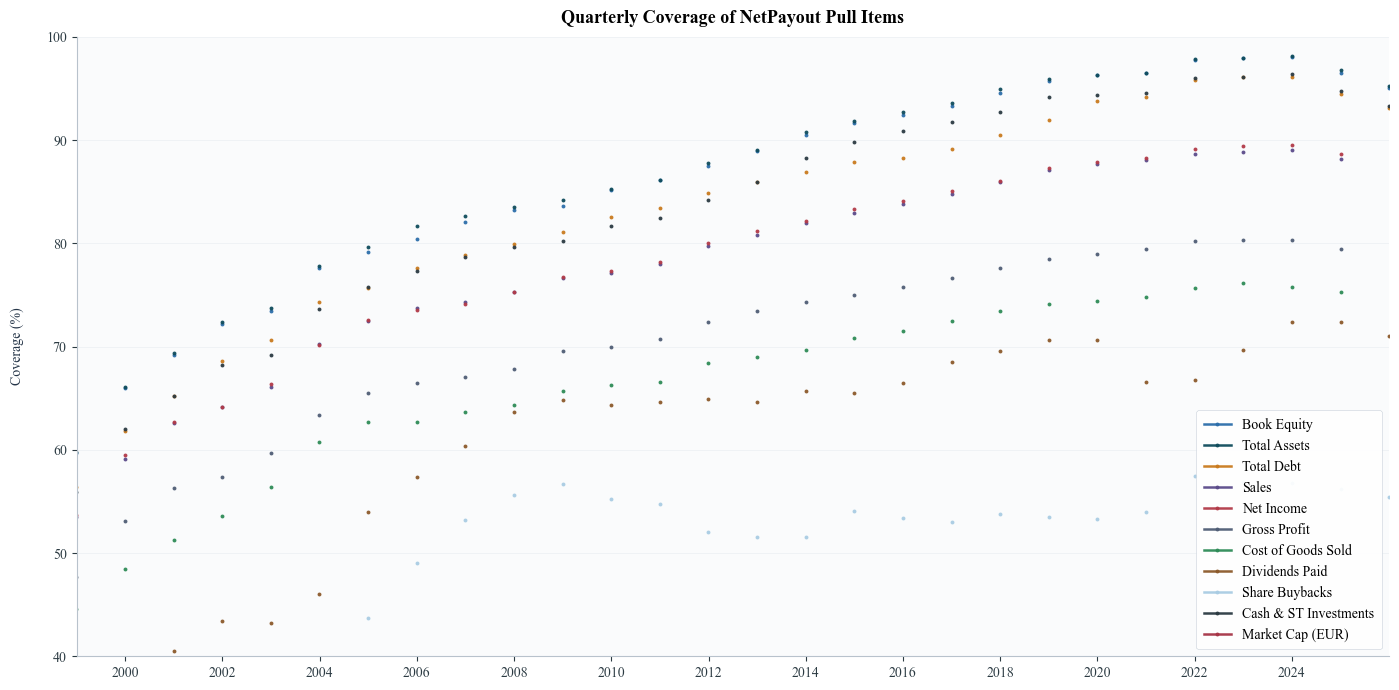

In [15]:
plot_items = [
    ('BE', 'Book Equity'),
    ('assets', 'Total Assets'),
    ('debt', 'Total Debt'),
    ('Sales', 'Sales'),
    ('NetIncome', 'Net Income'),
    ('GrossProfit', 'Gross Profit'),
    ('Cogs', 'Cost of Goods Sold'),
    ('Dividends', 'Dividends Paid'),
    ('Buybacks', 'Share Buybacks'),
    ('CashSTInvst', 'Cash & ST Investments'),
    ('mcap_eur', 'Market Cap (EUR)'),
]

coverage_frames = [
    np1_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['BE', 'assets', 'debt']]].copy(),
    np2_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Sales', 'NetIncome', 'GrossProfit', 'Cogs']]].copy(),
    np3_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Dividends']]].copy(),
    np6_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Buybacks']]].copy(),
    np4_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['CashSTInvst']]].copy(),
    np5_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['mcap_eur']]].copy(),
]

coverage_plot_df = coverage_frames[0]
for frame in coverage_frames[1:]:
    coverage_plot_df = coverage_plot_df.merge(frame, on='quarter', how='outer')

coverage_plot_df = coverage_plot_df.sort_values('quarter').reset_index(drop=True)

line_colors = [
    COLORS['blue'],
    COLORS['primary'],
    COLORS['orange'],
    COLORS['purple'],
    COLORS['accent'],
    COLORS['neutral'],
    COLORS['green'],
    COLORS['brown'],
    COLORS['blue_light'],
    COLORS['reference'],
    COLORS['red'],
]

fig, ax = plt.subplots(figsize=(14, 7))

for (item, label), color in zip(plot_items, line_colors):
    col = f'cov_{item}_pct'
    if col not in coverage_plot_df.columns:
        continue
    ax.plot(
        coverage_plot_df['quarter'],
        coverage_plot_df[col],
        label=label,
        color=color,
        linewidth=1.8,
        marker='o',
        markersize=2.8,
        markeredgewidth=0.0,
        alpha=0.95,
    )

ax.set_title('Quarterly Coverage of NetPayout Pull Items')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(40, 100)

style_axes(ax, grid_axis='y', grid_alpha=0.3)
style_time_axis(
    ax,
    x_min=coverage_plot_df['quarter'].min(),
    x_max=coverage_plot_df['quarter'].max(),
    x_ticks=coverage_plot_df['quarter'],
    date_fmt='%Y',
)
style_legend(ax, loc='lower right', title=None)

graphs_dir = BASE_DIR / 'graphs'
graphs_dir.mkdir(parents=True, exist_ok=True)
coverage_plot_path = graphs_dir / 'netpayout_coverage_quarterly.png'

fig.tight_layout()
fig.savefig(coverage_plot_path, dpi=220, bbox_inches='tight')

plt.show()


## 11. Finaler Output: Eine Tabelle mit allen gezogenen Items

Der einzige Tabellen-Output ist `euro500_netpayout.parquet`.
Er enthält genau eine Zeile je `firm_id,date` mit allen gezogenen Items.
Keine zusätzlichen Firmen-Metadaten werden angehängt.


In [16]:
FULL_HISTORY_BASE_COLS = ['BE', 'assets', 'debt', 'Sales', 'NetIncome', 'GrossProfit', 'Cogs', 'Dividends', 'Buybacks', 'CashSTInvst']
FULL_HISTORY_VALUE_COLS = [*FULL_HISTORY_BASE_COLS, 'mcap_eur']
MCAP_ASOF_TOL_DAYS = 90


def _load_module_full_history(cache_dir: Path, value_cols: list[str]) -> pd.DataFrame:
    rows = []
    cache_files = sorted(cache_dir.glob('*.parquet'))
    for fp in cache_files:
        try:
            hist = pd.read_parquet(fp).copy()
        except Exception as exc:
            print(f'Skipping unreadable cache file: {fp.name} | {exc}')
            continue

        if 'date' not in hist.columns:
            continue

        firm_id = fp.stem.split('__', 1)[0]
        hist['firm_id'] = firm_id
        hist['date'] = pd.to_datetime(hist['date'], errors='coerce').dt.normalize()
        hist = hist.dropna(subset=['firm_id', 'date']).copy()
        if hist.empty:
            continue

        keep_cols = ['firm_id', 'date'] + [c for c in value_cols if c in hist.columns]
        hist = hist[keep_cols].copy()
        for c in value_cols:
            if c not in hist.columns:
                hist[c] = np.nan
        rows.append(hist[['firm_id', 'date', *value_cols]])

    if not rows:
        return pd.DataFrame(columns=['firm_id', 'date', *value_cols])

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(['firm_id', 'date']).groupby(['firm_id', 'date'], as_index=False).agg({c: _first_valid for c in value_cols})
    return out.sort_values(['firm_id', 'date']).reset_index(drop=True)


def build_full_history_export() -> pd.DataFrame:
    module_specs = {'NP1': NP1_SPECS, 'NP2': NP2_SPECS, 'NP3': NP3_SPECS, 'NP6': NP6_SPECS, 'NP4': NP4_SPECS, 'NP5': NP5_SPECS}

    # 1) Build final base table from NP1/NP2/NP3/NP6/NP4 (no market cap yet).
    base_modules = ['NP1', 'NP2', 'NP3', 'NP6', 'NP4']
    base_frames = []
    for module_name in base_modules:
        module_value_cols = [s.output_col for s in module_specs[module_name]]
        module_hist = _load_module_full_history(MODULES[module_name]['cache_dir'], module_value_cols)
        base_frames.append(module_hist)

    if not base_frames:
        return pd.DataFrame(columns=['firm_id', 'date', *FULL_HISTORY_VALUE_COLS])

    base_history = base_frames[0].copy()
    for frame in base_frames[1:]:
        base_history = base_history.merge(frame, on=['firm_id', 'date'], how='outer')

    for c in FULL_HISTORY_BASE_COLS:
        if c not in base_history.columns:
            base_history[c] = np.nan

    base_history = base_history[['firm_id', 'date', *FULL_HISTORY_BASE_COLS]].copy()
    base_history = base_history.sort_values(['firm_id', 'date']).reset_index(drop=True)

    # 2) Map market cap from NP5 onto existing rows only (no row expansion).
    np5_value_cols = [s.output_col for s in module_specs['NP5']]
    np5_hist = _load_module_full_history(MODULES['NP5']['cache_dir'], np5_value_cols)

    if np5_hist.empty:
        out = base_history.copy()
        out['mcap_eur'] = np.nan
    else:
        np5_map = np5_hist[['firm_id', 'date', 'mcap_eur']].copy()
        np5_map['mcap_eur'] = pd.to_numeric(np5_map['mcap_eur'], errors='coerce')
        np5_map = np5_map.dropna(subset=['firm_id', 'date']).sort_values(['date', 'firm_id'])
        np5_map = np5_map.drop_duplicates(['firm_id', 'date'], keep='last')

        # As-of mapping: for each base row, take latest available market cap at or before that date.
        left = base_history.sort_values(['date', 'firm_id']).copy()
        out = pd.merge_asof(
            left,
            np5_map,
            by='firm_id',
            left_on='date',
            right_on='date',
            direction='backward',
            allow_exact_matches=True,
            tolerance=pd.Timedelta(days=MCAP_ASOF_TOL_DAYS),
        )

    for c in FULL_HISTORY_VALUE_COLS:
        if c not in out.columns:
            out[c] = np.nan

    out = out[['firm_id', 'date', *FULL_HISTORY_VALUE_COLS]].copy()
    out = out.sort_values(['firm_id', 'date']).reset_index(drop=True)
    return out


euro500_netpayout_full_history_df = build_full_history_export()
euro500_netpayout_full_history_df.to_parquet(OUTPUT_PATH, index=False)
euro500_netpayout_df = euro500_netpayout_full_history_df.copy()

print('Saved output:', OUTPUT_PATH)
print('rows:', len(euro500_netpayout_full_history_df), '| companies:', euro500_netpayout_full_history_df['firm_id'].nunique())
print('date range:', euro500_netpayout_full_history_df['date'].min(), '->', euro500_netpayout_full_history_df['date'].max())
print('mcap coverage (%):', round(float(pd.to_numeric(euro500_netpayout_full_history_df['mcap_eur'], errors='coerce').notna().mean() * 100.0), 2) if 'mcap_eur' in euro500_netpayout_full_history_df.columns else 0.0)
euro500_netpayout_full_history_df.head()

Saved output: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_netpayout.parquet
rows: 30104 | companies: 1245
date range: 1995-12-30 00:00:00 -> 2025-10-31 00:00:00
mcap coverage (%): 93.07


,firm_id,date,BE,assets,debt,Sales,NetIncome,GrossProfit,Cogs,Dividends,Buybacks,CashSTInvst,mcap_eur
0,FIRM0000001,1998-11-30,92670119.59117,201941375.2729,54100816.53313,296097820.36271,15384772.70519,145027942.10131,151069878.2614,10021320.87145,0.0,20117801.64943,138569059.780975
1,FIRM0000001,1999-11-30,104237075.81947,264407949.56617,101319133.05349,305313856.52127,15307056.33925,148917850.73345,156396005.78782,<NA>,<NA>,39481959.06597,121992375.0
2,FIRM0000001,2000-11-30,108772234.80568,265103817.81648,99152278.06098,379503331.06661,14892398.6236,184504276.95659,194999054.11002,11046972.38513,<NA>,21139362.82806,192793449.999999
3,FIRM0000001,2001-11-30,108458000.0,259187000.0,94053000.0,379731000.0,12857000.0,183741000.0,195990000.0,11888000.0,<NA>,28166000.0,176409250.0
4,FIRM0000001,2002-11-30,107209000.0,251266000.0,86852000.0,350488000.0,12126000.0,173302000.0,177186000.0,11995000.0,<NA>,29037000.0,162393850.0
